# **NLP PROJECT : PRODUCTS REVIEW CLASSIFICATION**

**Name : Zain ul abideen**

**SapId: 70158131**

**Subject : NLP**

<h1 style="color:red">Task # 3 - Preprocessing</h1>

## Objective
In this notebook, we perform **text preprocessing and data augmentation** on Amazon Product Reviews to prepare data for sentiment classification.

---

## Steps
1. [Import Libraries](#import)
2. [Load Dataset](#load)
3. [Initial Exploration](#explore)
4. [Word Spacing Correction]
5. [Data Cleaning & Preprocessing](#preprocess)
   - Removing HTML tags  
   - Removing punctuation & special characters  
   - Stopword removal  
   - Lemmatization  
   - Text normalization  
   - Whitespace removal  
   - Handling OOV words  
   - Removing duplicates  
   - Handling missing values  
6. [Data Augmentation](#augment)
7. [Vectorization](#vector)
8. [Export Cleaned Dataset](#export)


In [1]:
# 🔹 Importing libraries
import pandas as pd
import numpy as np
import re
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from bs4 import BeautifulSoup
from sklearn.feature_extraction.text import TfidfVectorizer
import random
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize



# Download required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


## Step 1: Load Dataset <a id="load"></a>

We will load our Amazon Product Reviews dataset, inspect the first few records, and identify useful columns for text analysis.


In [2]:
# Load dataset
df = pd.read_csv("/kaggle/input/Amazon-Product-Reviews - Amazon Product Review (1).csv")

# Show basic info
df.info()
df.head()

# --- Keep only important columns ---
df = df[['review_body', 'sentiment', 'star_rating', 'helpful_votes']]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30846 entries, 0 to 30845
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   marketplace        30846 non-null  object
 1   customer_id        30846 non-null  int64 
 2   review_id          30846 non-null  object
 3   product_id         30846 non-null  object
 4   product_parent     30846 non-null  int64 
 5   product_title      30846 non-null  object
 6   product_category   30846 non-null  object
 7   star_rating        30846 non-null  int64 
 8   helpful_votes      30846 non-null  int64 
 9   total_votes        30846 non-null  int64 
 10  vine               30846 non-null  object
 11  verified_purchase  30846 non-null  object
 12  review_headline    30844 non-null  object
 13  review_body        30842 non-null  object
 14  review_date        30846 non-null  object
 15  sentiment          30846 non-null  int64 
dtypes: int64(6), object(10)
memory usage: 3.

## Step 2: Initial Exploration <a id="explore"></a>

Let's check for missing values, duplicates, and distribution of sentiment classes to understand our dataset better.


In [3]:
# Check missing values
print(df.isnull().sum())

# Check duplicates
print("Duplicates:", df.duplicated().sum())

# Class distribution
print("\nSentiment Class Distribution:")
print(df['sentiment'].value_counts())

review_body      4
sentiment        0
star_rating      0
helpful_votes    0
dtype: int64
Duplicates: 2813

Sentiment Class Distribution:
sentiment
1    25767
0     5079
Name: count, dtype: int64


## Step 3: Data Cleaning & Preprocessing <a id="preprocess"></a>

We’ll perform:
- HTML tag removal  
- Special character and punctuation removal  
- Stopword removal  
- Lemmatization  
- Text normalization (lowercasing)  
- Whitespace trimming  
- Handling missing and duplicate records


In [4]:
# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if pd.isnull(text):
        return ""
    text = BeautifulSoup(text, "html.parser").get_text()                # Remove HTML tags
    text = re.sub(r"[^a-zA-Z\s]", "", text)                             # Remove punctuation/special chars
    text = text.lower()                                                 # Lowercase
    words = text.split()
    words = [w for w in words if w not in stop_words]                   # Remove stopwords
    words = [lemmatizer.lemmatize(w) for w in words]                    # Lemmatization
    return " ".join(words).strip()

# Apply cleaning
df['cleaned_text'] = df['review_body'].apply(clean_text)

# Remove duplicates and missing values
df.drop_duplicates(subset=['cleaned_text'], inplace=True)
df.dropna(subset=['cleaned_text'], inplace=True)

print("✅ Cleaning completed. Total records:", len(df))


✅ Cleaning completed. Total records: 25577


##  Step 4: Word Spacing Correction
In this step, we use the **WordSegment** library to handle run-on words where users accidentally type multiple words together, such as:
> "amazonnetflixhullu" → "amazon netflix hullu"

This ensures our tokenizer and vectorizer can correctly interpret separate words, improving the accuracy of our NLP model later.


In [5]:
# Install library for smart spacing correction
!pip install wordsegment

from wordsegment import load, segment
load()

def smart_spacing(text):
    """
    Corrects words that are joined together without spaces,
    e.g. 'amazonnetflixhullu' -> 'amazon netflix hullu'
    """
    try:
        # Apply segmentation on each token individually
        return " ".join(segment(text))
    except:
        return text  # fallback if segmentation fails

# Apply to cleaned text column
df['cleaned_text'] = df['cleaned_text'].apply(lambda x: " ".join([smart_spacing(w) for w in x.split()]))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 77.5 MB/s eta 0:00:00ta 0:00:01


## Step 5: Handle Missing & OOV Words

We handle null or unknown tokens and remove columns not needed for training.


In [6]:
# Replace empty strings with a placeholder
df['cleaned_text'].replace('', np.nan, inplace=True)
df.dropna(subset=['cleaned_text'], inplace=True)

# Drop unrelated columns
df = df[['cleaned_text', 'sentiment','star_rating', 'helpful_votes']]

print("✅ Nulls handled and irrelevant columns removed.")


✅ Nulls handled and irrelevant columns removed.


/tmp/ipykernel_38/2945593360.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cleaned_text'].replace('', np.nan, inplace=True)


## Step 6: Data Augmentation & Tokenization <a id="augment"></a>

To make our model more robust, we’ll use **Synonym Replacement** from WordNet to generate slightly modified versions of reviews.


In [7]:
def synonym_replacement(text, n=2):
    words = text.split()
    new_words = words.copy()
    random_word_list = list(set([word for word in words if word.isalpha()]))
    random.shuffle(random_word_list)
    num_replaced = 0

    for random_word in random_word_list:
        synonyms = wordnet.synsets(random_word)
        if not synonyms:
            continue
        synonym_words = set()
        for syn in synonyms:
            for lemma in syn.lemmas():
                synonym_words.add(lemma.name())
        synonym_words.discard(random_word)
        if len(synonym_words) >= 1:
            synonym = random.choice(list(synonym_words))
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break
    return ' '.join(new_words)

# Apply augmentation to 10% of dataset
sample_df = df.sample(frac=0.1, random_state=42)
sample_df['cleaned_text'] = sample_df['cleaned_text'].apply(lambda x: synonym_replacement(str(x)))
df_augmented = pd.concat([df, sample_df], ignore_index=True)

print(f"✅ Data augmentation done! New dataset size: {len(df_augmented)}")

# Download tokenizer if not already done
nltk.download('punkt')

# Tokenization function
def tokenize_text(text):
    return word_tokenize(text)

# Apply tokenization to your dataframe
df_augmented['tokens'] = df_augmented['cleaned_text'].apply(tokenize_text)

# Check the first few rows
print(df_augmented[['cleaned_text']].head())


✅ Data augmentation done! New dataset size: 28134


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


                                        cleaned_text
0                                         great love
1  lot ads slow processing speed occasionally shu...
2  excellent unit versatility tablet besides comp...
3  bought amazon prime ended buying gb one camera...
4           amazon product continue meet expectation


## Step 7: Text Vectorization <a id="vector"></a>

We convert text into numerical form using **TF-IDF Vectorization**, which measures how important each word is within the corpus.


In [8]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df_augmented['cleaned_text']).toarray()

print("✅ TF-IDF vectorization complete.")
print("Shape of feature matrix:", X.shape)


✅ TF-IDF vectorization complete.
Shape of feature matrix: (28134, 5000)


## Step 8: Export Cleaned & Augmented Dataset <a id="export"></a>

We’ll save the processed dataset as a CSV file for use in model training (CNN, LSTM, or BERT).


In [9]:
df_augmented.to_csv("/kaggle/working/cleaned_augmented_reviews.csv", index=False)
print("📁 Saved cleaned_augmented_reviews.csv successfully!")


📁 Saved cleaned_augmented_reviews.csv successfully!


<h1 style="color:red">Task 4 — Text Representation Techniques</h1>

In this task, we applied three widely used text representation techniques on the preprocessed product reviews dataset.  
These techniques convert text into numerical format so that machine learning models can understand and learn from it.

The three techniques used are:

1. **TF-IDF (Term Frequency – Inverse Document Frequency)**
2. **Bag of Words (CountVectorizer)**
3. **One-Hot Encoding (Binary CountVectorizer)**

Each technique is applied separately, and the output is saved as an Excel file.

## Steps 

We begin by loading the already preprocessed CSV file that contains the cleaned text.  
This includes steps like tokenization, stopword removal, punctuation removal, and normalization.

## Technique 1 — TF-IDF (Term Frequency – Inverse Document Frequency)

TF-IDF is a text representation method that assigns higher weights to rare but important words  
and lower weights to common words.

**Why TF-IDF?**
- Helps highlight meaningful words.
- Reduces the weight of very frequent but less informative words like “good”, “product”, etc.
- Performs better than Bag of Words for many classification tasks.

We use `TfidfVectorizer` to convert text into TF-IDF feature vectors.


## Technique 2 — Bag of Words (CountVectorizer)

Bag of Words (BoW) is one of the simplest text representation methods.  
It counts how many times each word appears in the text.

**Important characteristics:**
- Only considers word frequency.
- Does not care about word order.
- Dimension becomes large as vocabulary grows.

We use `CountVectorizer` to generate frequency-based feature vectors.

## Technique 3 — One-Hot Encoding (Binary CountVectorizer)

One-Hot Encoding represents each word as **1 if the word exists in the text**,  
and **0 if it does not exist**, regardless of frequency.

This is similar to Bag of Words but uses binary values instead of frequencies.

**When is OHE useful?**
- When we only care about presence/absence of words.
- Useful in simple or small datasets.

We use CountVectorizer with the `binary=True` parameter.

In [10]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Load your preprocessed data
df = pd.read_csv('/kaggle/working/cleaned_augmented_reviews.csv')  # replace with your file
df_sample = df.sample(n=5000, random_state=42)  # random 5000 rows

texts = df_sample['cleaned_text'].tolist()

# 1️⃣ TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=3000)
X_tfidf = tfidf_vectorizer.fit_transform(texts)
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
tfidf_df.to_excel('tfidf_features.xlsx', index=False)
print("✅ TF-IDF Excel saved")

# 2️⃣ Bag-of-Words (CountVectorizer)
bow_vectorizer = CountVectorizer(max_features=3000)
X_bow = bow_vectorizer.fit_transform(texts)
bow_df = pd.DataFrame(X_bow.toarray(), columns=bow_vectorizer.get_feature_names_out())
bow_df.to_excel('bow_features.xlsx', index=False)
print("✅ Bag-of-Words Excel saved")

# 3️⃣ One-Hot Encoding (binary presence/absence)
ohe_vectorizer = CountVectorizer(max_features=3000, binary=True)
X_ohe = ohe_vectorizer.fit_transform(texts)
ohe_df = pd.DataFrame(X_ohe.toarray(), columns=ohe_vectorizer.get_feature_names_out())
ohe_df.to_excel('ohe_features.xlsx', index=False)
print("✅ One-Hot Encoding Excel saved")


✅ TF-IDF Excel saved
✅ Bag-of-Words Excel saved
✅ One-Hot Encoding Excel saved


## Summary

We successfully generated three separate text representations :

- **bow_features.xlsx**
- **ohe_features.xlsx**
- **tfidf_features.xlsx**  


<h1 style="color:red">Task 5 - Embeddings</h1>

## STEP 1 — Load your cleaned CSV

In [11]:
import pandas as pd

df = pd.read_csv("/kaggle/working/cleaned_augmented_reviews.csv") 
df.head()

,cleaned_text,sentiment,star_rating,helpful_votes,tokens
0,great love,1,5,0,"['great', 'love']"
1,lot ads slow processing speed occasionally shu...,0,3,0,"['lot', 'ads', 'slow', 'processing', 'speed', ..."
2,excellent unit versatility tablet besides comp...,1,5,0,"['excellent', 'unit', 'versatility', 'tablet',..."
3,bought amazon prime ended buying gb one camera...,1,4,0,"['bought', 'amazon', 'prime', 'ended', 'buying..."
4,amazon product continue meet expectation,1,5,0,"['amazon', 'product', 'continue', 'meet', 'exp..."


## STEP 2 -- Word2Vec Embeddings
Word2Vec learns embeddings by analyzing the context of words in a sliding window.
We train our own Word2Vec model on the cleaned dataset.

We use:
- vector_size = 100
- window = 5
- min_count = 2

After training, we convert each sentence into an averaged embedding and export to Excel.

In [12]:
from gensim.models import Word2Vec
import numpy as np

sentences = df['tokens'].tolist()

w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2)

def get_sentence_vector(tokens):
    vectors = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
    return np.mean(vectors, axis=0) if len(vectors) > 0 else np.zeros(100)

df_w2v = df['tokens'].apply(get_sentence_vector).apply(pd.Series)
df_w2v.to_excel("word2vec_embeddings.xlsx", index=False)


## STEP 3 -- GloVe Embeddings
GloVe uses global co-occurrence statistics to build embeddings.
We load the 100-dimensional GloVe vectors and convert each sentence
into an averaged embedding.

In [13]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip
glove_path = "glove.6B.100d.txt"

--2025-12-19 11:33:58--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-12-19 11:33:58--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-12-19 11:33:59--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [14]:
import numpy as np

glove_path = "/kaggle/working/glove.6B.100d.txt"
glove = {}

with open(glove_path, "r", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        glove[word] = vector

def glove_sentence_vector(tokens):
    vectors = [glove[word] for word in tokens if word in glove]
    return np.mean(vectors, axis=0) if len(vectors) > 0 else np.zeros(100)

df_glove = df['tokens'].apply(glove_sentence_vector).apply(pd.Series)
df_glove.to_excel("glove_embeddings.xlsx", index=False)


## STEP 4 -- FastText Embeddings
FastText considers subword information, which helps with misspelled and unknown words.
We use the pretrained 'FastText Wiki News 300d' model.

In [15]:
!wget https://dl.fbaipublicfiles.com/fasttext/vectors-english/wiki-news-300d-1M.vec.zip
!unzip wiki-news-300d-1M.vec.zip

!unzip /kaggle/working/wiki-news-300d-1M.vec.zip.1 -d /kaggle/working/

--2025-12-19 11:37:54--  https://dl.fbaipublicfiles.com/fasttext/vectors-english/wiki-news-300d-1M.vec.zip
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.227.219.33, 13.227.219.70, 13.227.219.59, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.227.219.33|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 681808098 (650M) [application/zip]
Saving to: ‘wiki-news-300d-1M.vec.zip’

wiki-news-300d-1M.v 100%[===================>] 650.22M  70.5MB/s    in 8.9s    

2025-12-19 11:38:04 (73.4 MB/s) - ‘wiki-news-300d-1M.vec.zip’ saved [681808098/681808098]

Archive:  wiki-news-300d-1M.vec.zip
  inflating: wiki-news-300d-1M.vec   
unzip:  cannot find or open /kaggle/working/wiki-news-300d-1M.vec.zip.1, /kaggle/working/wiki-news-300d-1M.vec.zip.1.zip or /kaggle/working/wiki-news-300d-1M.vec.zip.1.ZIP.


In [16]:

from gensim.models import KeyedVectors

import numpy as np
import pandas as pd

ft = KeyedVectors.load_word2vec_format("wiki-news-300d-1M.vec")

def fasttext_sentence_vector(tokens):
    vectors = [ft[word] for word in tokens if word in ft]
    return np.mean(vectors, axis=0) if len(vectors) else np.zeros(300)

df_fasttext = df['tokens'].apply(fasttext_sentence_vector).apply(pd.Series)
df_fasttext.to_excel("fasttext_embeddings.xlsx", index=False)


<h1 style="color:red">Task 6 - Model Definition – BiLSTM Hybrid Model</h1>

## Purpose of the Model

The hybrid BiLSTM + Embedding model is designed for binary sentiment classification of product reviews into Positive and Negative categories.

## This model leverages:

## Pre-trained Word Embeddings:
Embeddings such as GloVe, Word2Vec, and FastText provide rich semantic representations of words, capturing relationships between words learned from large corpora.

## Bidirectional LSTM Layers:
BiLSTM layers process text sequences in both forward and backward directions, capturing context from past and future words. This is especially useful in sentiment analysis, where word order and context significantly affect meaning.

By combining pre-trained embeddings with BiLSTM layers, the model benefits from both semantic knowledge and sequence learning, improving sentiment classification performance.

## Architecture Overview

The model consists of the following components:

### Input Layer

Receives tokenized and padded sequences of text reviews.

Maximum sequence length is set to 100 tokens.

### Embedding Layer

Initialized with a pre-trained embedding matrix (GloVe, Word2Vec, or FastText).

Embeddings are non-trainable to retain pre-trained knowledge.

Each token is converted into a dense vector representation.

### BiLSTM Layers

### First BiLSTM: 64 units, returns sequences to pass information to the next layer.

### Second BiLSTM: 32 units, outputs a single vector summarizing the sequence.

Bidirectional processing captures dependencies in both directions of the text.

Dense & Dropout Layers

Fully connected Dense layer with 64 units and ReLU activation integrates features from the BiLSTM output.

Dropout layer with 0.4 rate prevents overfitting by randomly disabling neurons during training.

### Output Layer

Single neuron with sigmoid activation to predict binary sentiment: Positive or Negative.

## How the Model Processes Input
Step 1: Text Preprocessing

Reviews are cleaned, tokenized, and converted to sequences of integers.

Sequences are padded to a fixed length of 100 tokens.

Step 2: Embedding Layer

Tokens are mapped to pre-trained embeddings (GloVe, Word2Vec, or FastText).

Embeddings provide semantic understanding of words.

Step 3: BiLSTM Layers

Sequential embeddings are fed into bidirectional LSTM layers.

First BiLSTM captures sequence patterns; second BiLSTM compresses sequence information into a single feature vector.

Step 4: Dense & Dropout Layers

Dense layer combines features extracted from BiLSTM output.

Dropout regularizes the model to reduce overfitting.

Step 5: Output Layer

Produces a probability score for the Positive sentiment class.

Threshold 0.5 is used to classify reviews as Positive or Negative.

## Optional Code Snippet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

def build_model(embedding_matrix, embedding_dim, max_len):
    model = Sequential([
        Embedding(input_dim=embedding_matrix.shape[0],
                  output_dim=embedding_dim,
                  weights=[embedding_matrix],
                  input_length=max_len,
                  trainable=False,
                  name='embedding'),
        Bidirectional(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2), name='bilstm_1'),
        Bidirectional(LSTM(32, dropout=0.2, recurrent_dropout=0.2), name='bilstm_2'),
        Dense(64, activation='relu', name='dense_1'),
        Dropout(0.4, name='dropout'),
        Dense(1, activation='sigmoid', name='output')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', 'Precision', 'Recall']
    )
    
    return model

## Summary

The BiLSTM hybrid model with pre-trained embeddings is an effective approach for binary sentiment classification of product reviews.

Pre-trained embeddings provide semantic understanding of words from large corpora.

Bidirectional LSTM layers capture sequential dependencies and contextual information in both directions.

Dense and Dropout layers combine features and prevent overfitting.

The sigmoid output layer generates predictions for Positive or Negative sentiment.

This architecture balances pre-trained semantic knowledge with sequence modeling, achieving robust performance for real-world review classification tasks. Multiple embeddings (GloVe, Word2Vec, FastText) allow comparison of semantic effectiveness

# Task 7 - Model Training ( BiLSTM )

2025-12-19 11:43:07.952483: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766144588.165934      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766144588.228043      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


🚀 COMPLETE PROFESSIONAL NLP MODEL TRAINING
Features: Balanced Dataset + All Visualizations + Fast Training

📂 Loading dataset...
✅ Total reviews: 28134

📊 Initial Class Distribution:
sentiment
1    22628
0     5506
Name: count, dtype: int64

⚖️ Balancing dataset...
✅ Balanced dataset created: 8000 reviews
   Positive: 4000 (50%)
   Negative: 4000 (50%)

📊 Data Split:
   Training:    5440 samples (Pos: 2720, Neg: 2720)
   Validation:   960 samples (Pos: 480, Neg: 480)
   Testing:     1600 samples (Pos: 800, Neg: 800)

🔤 Tokenizing text...
✅ Vocabulary size: 7737

📦 Loading pre-trained embeddings...
   Loading GloVe...
   ✅ GloVe: 400000 vectors loaded
   Training Word2Vec on dataset...
   ✅ Word2Vec: Trained on 8000 sentences
   Loading FastText...
   ✅ FastText: Loaded

🔨 Creating embedding matrices...
      Coverage: 7466/7737 (96.5%)
      Coverage: 5089/7737 (65.8%)
      Coverage: 7547/7737 (97.5%)
✅ All embedding matrices created

======================🎯 STARTING MODEL TRAINING===

I0000 00:00:1766144767.389414      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1766144767.390092      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



🔥 TRAINING: GloVe + BiLSTM
Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 61s 544ms/step - accuracy: 0.6328 - loss: 0.6371 - precision: 0.6444 - recall: 0.6332 - val_accuracy: 0.7583 - val_loss: 0.5163 - val_precision: 0.8563 - val_recall: 0.6208 - learning_rate: 0.0010
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 44s 513ms/step - accuracy: 0.7623 - loss: 0.5044 - precision: 0.7787 - recall: 0.7288 - val_accuracy: 0.8260 - val_loss: 0.4222 - val_precision: 0.8395 - val_recall: 0.8062 - learning_rate: 0.0010
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 44s 515ms/step - accuracy: 0.7900 - loss: 0.4686 - precision: 0.7905 - recall: 0.7877 - val_accuracy: 0.8031 - val_loss: 0.4470 - val_precision: 0.8819 - val_recall: 0.7000 - learning_rate: 0.0010
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 44s 515ms/step - accuracy: 0.8007 - loss: 0.4424 - precision: 0.8183 - recall: 0.7746 - val_accuracy: 0.8292 - val_loss: 0.4048 - val_precision: 0.8527 - val_recall: 0.7958 - learning_rate: 0.0010
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━

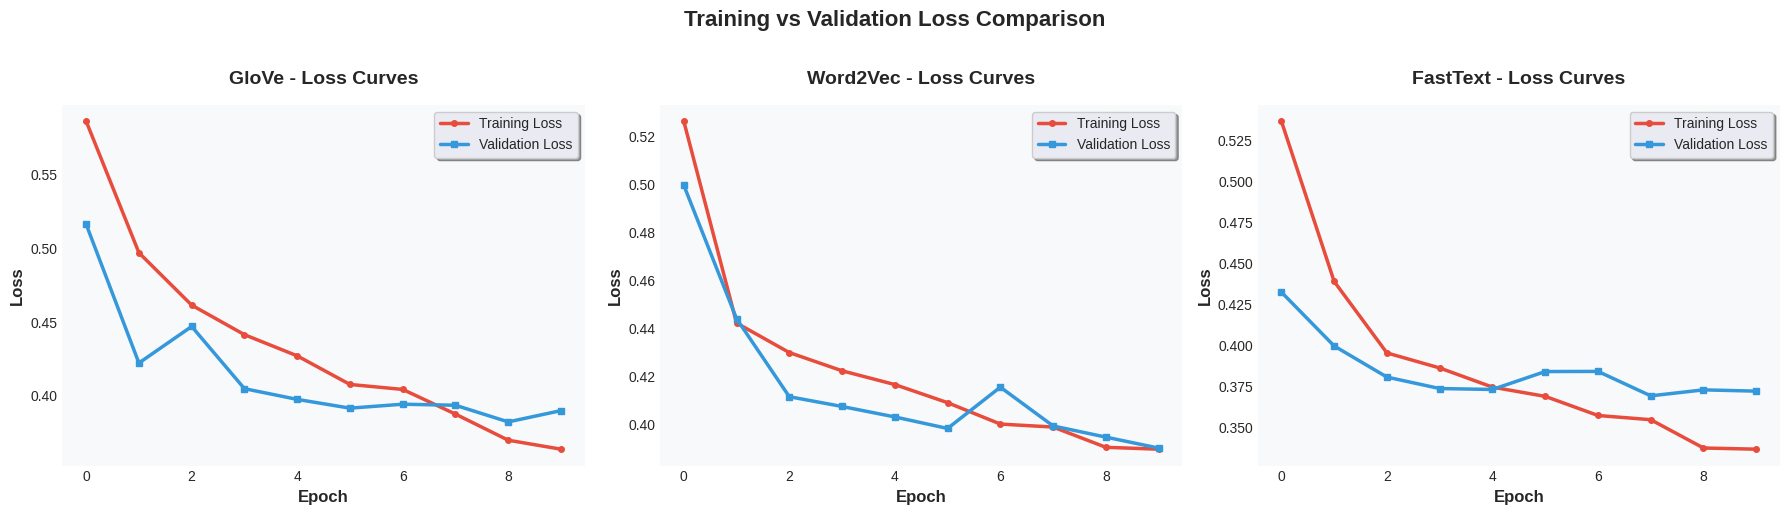

   ✅ Saved: 01_loss_curves.png

2️⃣ Creating Accuracy Curves...


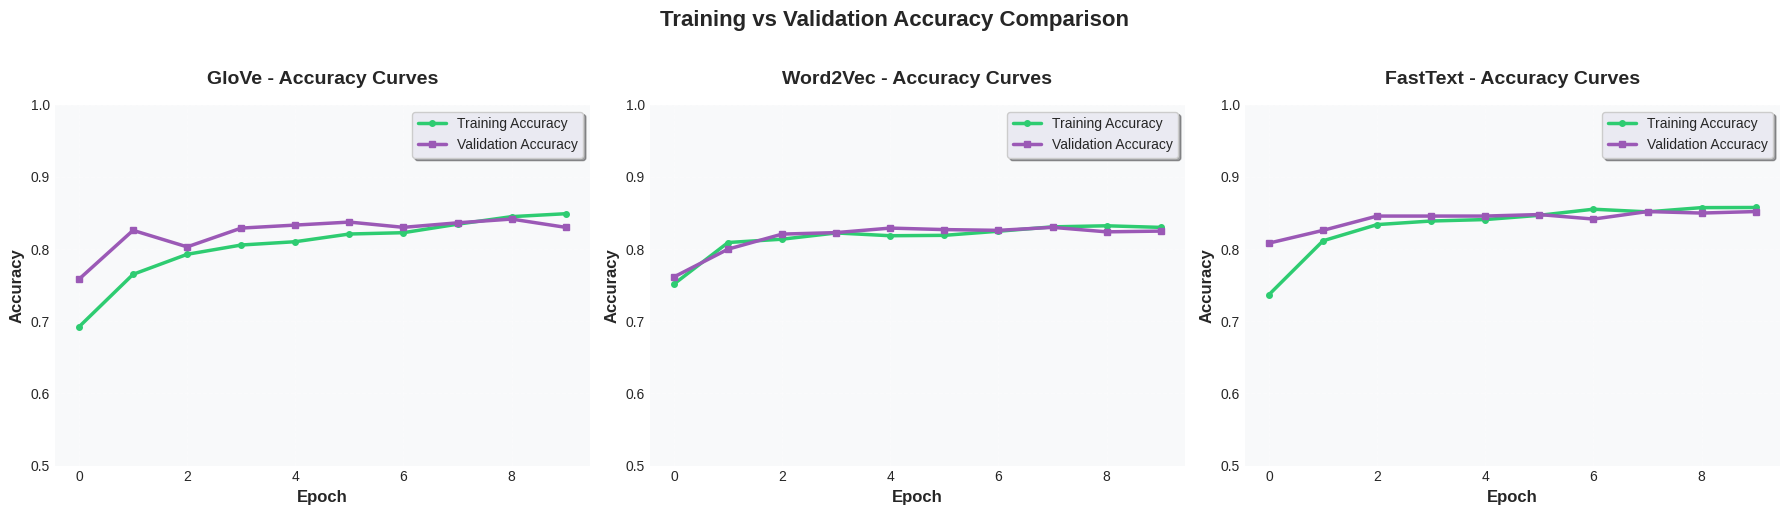

   ✅ Saved: 02_accuracy_curves.png

3️⃣ Creating F1-Score Comparison...


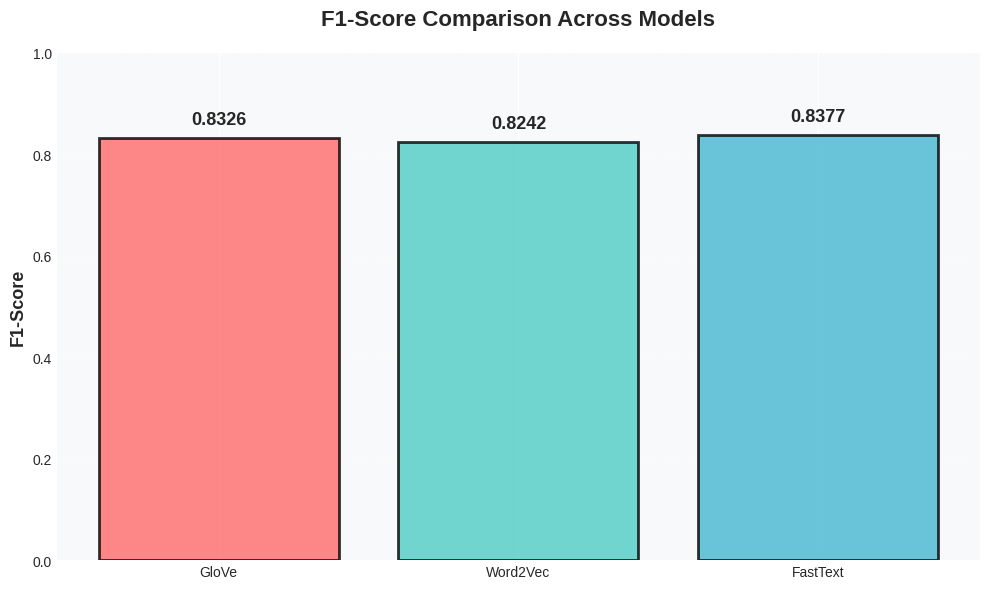

   ✅ Saved: 03_f1_comparison.png

4️⃣ Creating Complete Metrics Comparison...


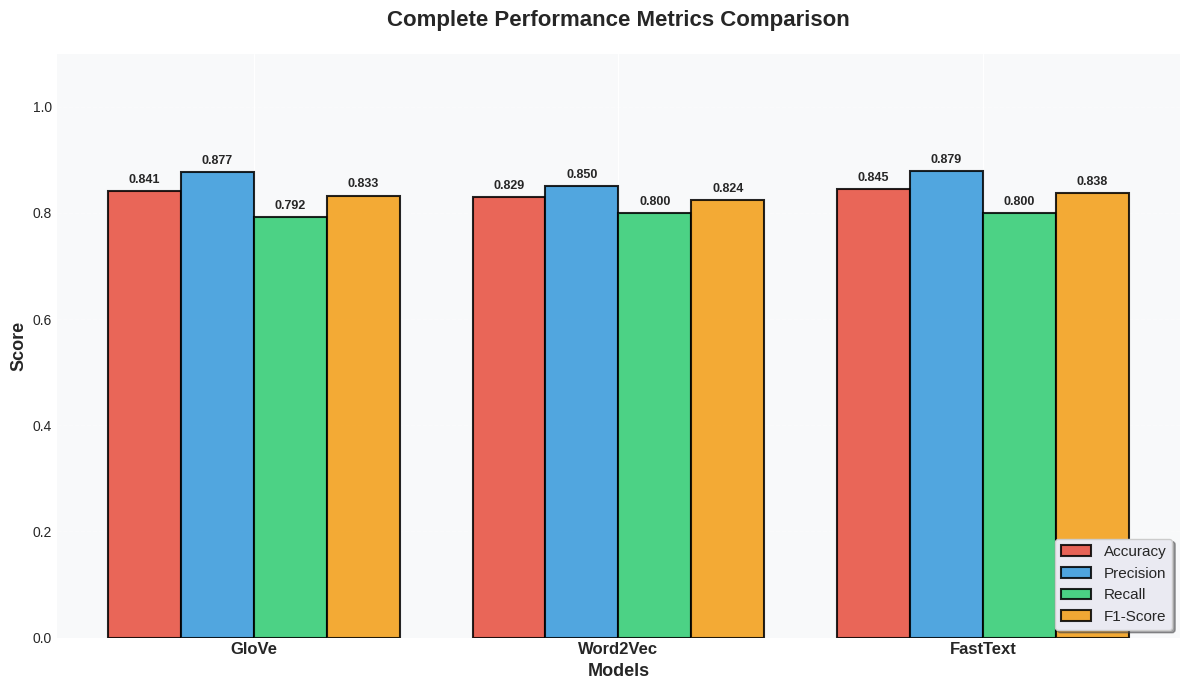

   ✅ Saved: 04_all_metrics_comparison.png

5️⃣ Creating Confusion Matrices...


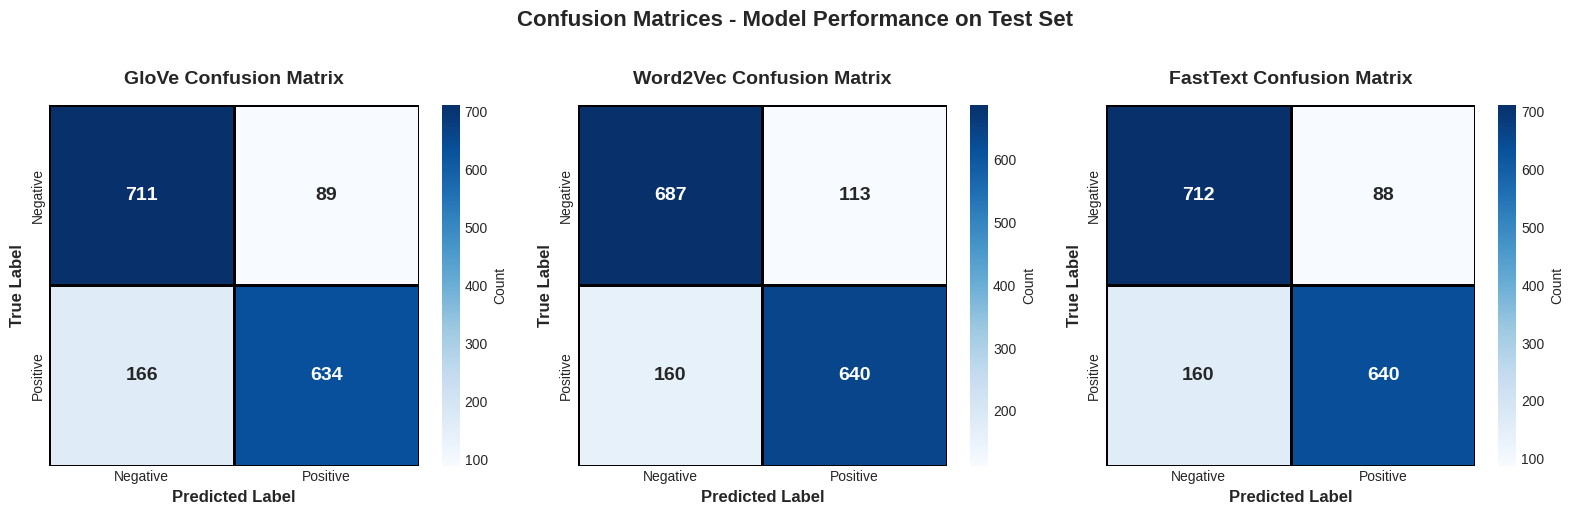

   ✅ Saved: 05_confusion_matrices.png

6️⃣ Creating ROC Curves...


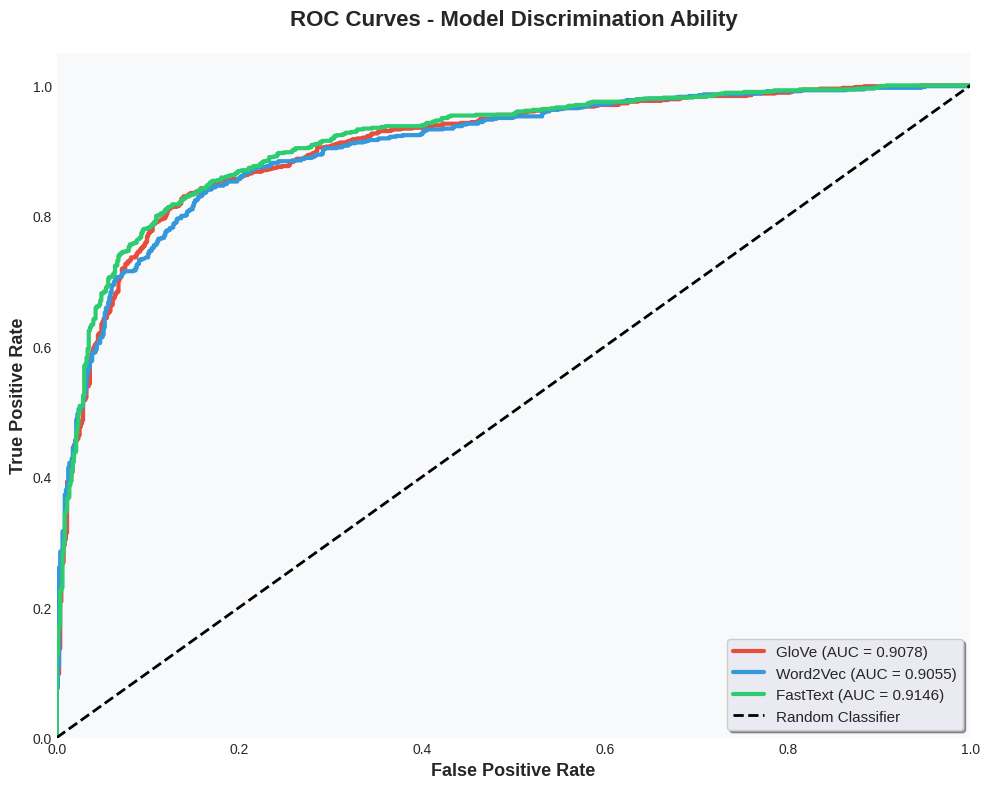

   ✅ Saved: 06_roc_curves.png

7️⃣ Creating Model Size Comparison...


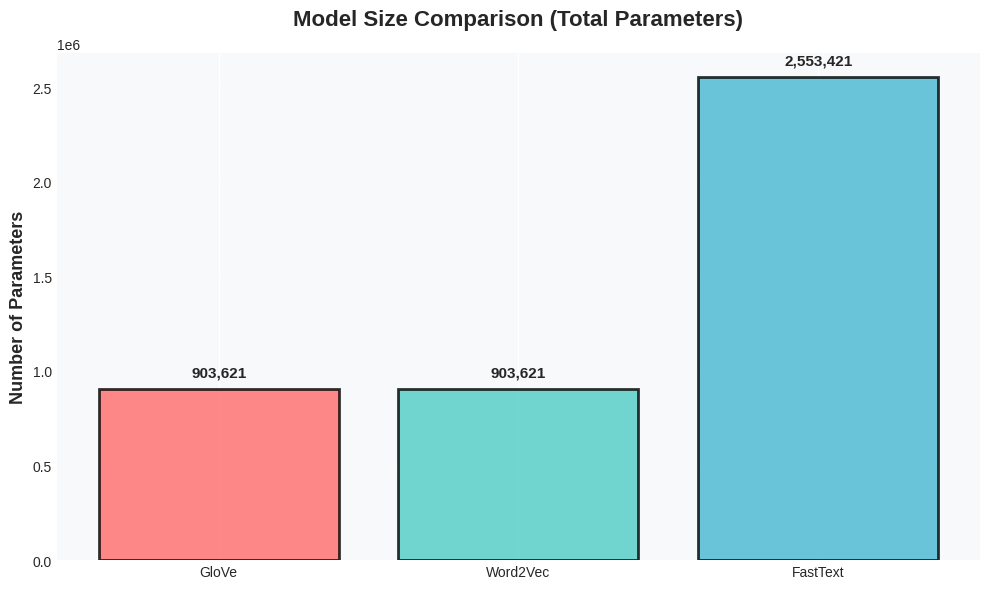

   ✅ Saved: 07_model_size_comparison.png

8️⃣ Creating Per-Class Performance Analysis...


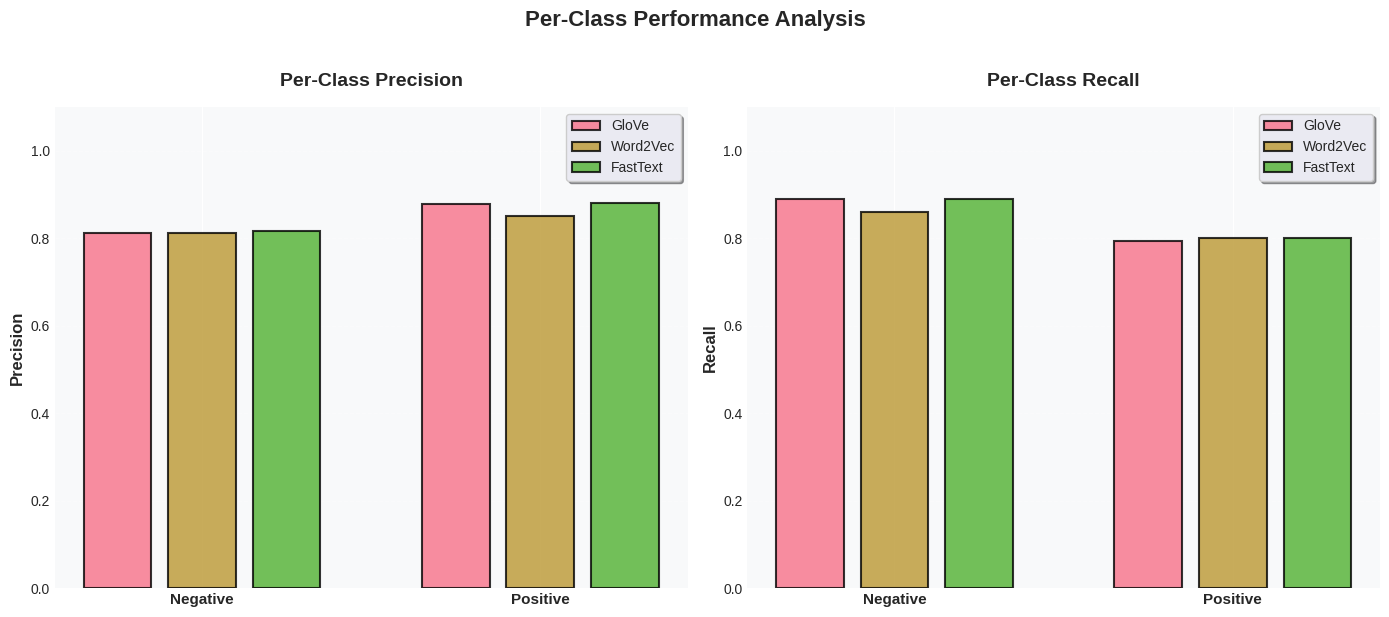

   ✅ Saved: 08_per_class_performance.png

                    📊 FINAL RESULTS SUMMARY TABLE                     
   Model Accuracy Precision Recall F1-Score Parameters
   GloVe   0.8406    0.8769 0.7925   0.8326    903,621
Word2Vec   0.8294    0.8499 0.8000   0.8242    903,621
FastText   0.8450    0.8791 0.8000   0.8377  2,553,421

✅ Summary saved to: model_performance_summary.csv

                         🎉 TRAINING COMPLETE!                         

📁 Files Generated:
   Models:
      ✅ glove_model_final.h5
      ✅ word2vec_model_final.h5
      ✅ fasttext_model_final.h5
      ✅ tokenizer_final.pkl

   Visualizations (8 graphs):
      ✅ 01_loss_curves.png
      ✅ 02_accuracy_curves.png
      ✅ 03_f1_comparison.png
      ✅ 04_all_metrics_comparison.png
      ✅ 05_confusion_matrices.png
      ✅ 06_roc_curves.png
      ✅ 07_model_size_comparison.png
      ✅ 08_per_class_performance.png

   Data:
      ✅ model_performance_summary.csv

📈 Model Performance:
   GloVe     : Accuracy=0.8406, 

In [17]:
# ============================================================
# COMPLETE PROFESSIONAL MODEL TRAINING
# With ALL Visualizations and Proper Balanced Training
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report, roc_curve, auc
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from gensim.models import Word2Vec, KeyedVectors
import warnings
warnings.filterwarnings('ignore')

print("🚀 COMPLETE PROFESSIONAL NLP MODEL TRAINING")
print("="*70)
print("Features: Balanced Dataset + All Visualizations + Fast Training")
print("="*70)

# ============================================================
# STEP 1: LOAD AND BALANCE DATASET
# ============================================================

print("\n📂 Loading dataset...")
df = pd.read_csv('/kaggle/working/cleaned_augmented_reviews.csv')
print(f"✅ Total reviews: {len(df)}")

# Check initial distribution
print("\n📊 Initial Class Distribution:")
print(df['sentiment'].value_counts())

# Balance dataset
print("\n⚖️ Balancing dataset...")
df_positive = df[df['sentiment'] == 1]
df_negative = df[df['sentiment'] == 0]

# Use 4000 of each for speed + quality balance
n_samples = 4000
df_pos_sampled = df_positive.sample(n=n_samples, random_state=42)
df_neg_sampled = df_negative.sample(n=n_samples, random_state=42)

df_balanced = pd.concat([df_pos_sampled, df_neg_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✅ Balanced dataset created: {len(df_balanced)} reviews")
print(f"   Positive: {(df_balanced['sentiment']==1).sum()} (50%)")
print(f"   Negative: {(df_balanced['sentiment']==0).sum()} (50%)")

# Prepare data
X = df_balanced['cleaned_text'].values
y = df_balanced['sentiment'].values

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

print(f"\n📊 Data Split:")
print(f"   Training:   {len(X_train):5d} samples (Pos: {(y_train==1).sum()}, Neg: {(y_train==0).sum()})")
print(f"   Validation: {len(X_val):5d} samples (Pos: {(y_val==1).sum()}, Neg: {(y_val==0).sum()})")
print(f"   Testing:    {len(X_test):5d} samples (Pos: {(y_test==1).sum()}, Neg: {(y_test==0).sum()})")

# ============================================================
# STEP 2: TOKENIZATION
# ============================================================

print("\n🔤 Tokenizing text...")

max_words = 8000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len, padding='post')
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=max_len, padding='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len, padding='post')

vocab_size = len(tokenizer.word_index) + 1
print(f"✅ Vocabulary size: {vocab_size}")

# ============================================================
# STEP 3: LOAD EMBEDDINGS
# ============================================================

print("\n📦 Loading pre-trained embeddings...")

# GloVe
print("   Loading GloVe...")
glove_embeddings = {}
with open("/kaggle/working/glove.6B.100d.txt", 'r', encoding='utf8') as f:
    for line in f:
        values = line.split()
        if len(values) > 2:
            glove_embeddings[values[0]] = np.asarray(values[1:], dtype='float32')
print(f"   ✅ GloVe: {len(glove_embeddings)} vectors loaded")

# Word2Vec - Train on balanced data
print("   Training Word2Vec on dataset...")
sentences = df_balanced['tokens'].apply(lambda x: eval(x) if isinstance(x, str) else x).tolist()
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4, sg=1, epochs=5)
print(f"   ✅ Word2Vec: Trained on {len(sentences)} sentences")

# FastText
print("   Loading FastText...")
fasttext_model = KeyedVectors.load_word2vec_format("/kaggle/working/wiki-news-300d-1M.vec")
print(f"   ✅ FastText: Loaded")

# Create embedding matrices
def create_embedding_matrix(embeddings_dict, embedding_dim):
    matrix = np.zeros((vocab_size, embedding_dim))
    found = 0
    for word, idx in tokenizer.word_index.items():
        if idx >= max_words:
            continue
        vec = embeddings_dict.get(word)
        if vec is not None:
            matrix[idx] = vec
            found += 1
    coverage = found / min(vocab_size, max_words) * 100
    print(f"      Coverage: {found}/{min(vocab_size, max_words)} ({coverage:.1f}%)")
    return matrix

print("\n🔨 Creating embedding matrices...")
glove_matrix = create_embedding_matrix(glove_embeddings, 100)
w2v_matrix = create_embedding_matrix({w: w2v_model.wv[w] for w in tokenizer.word_index.keys() if w in w2v_model.wv}, 100)
ft_matrix = create_embedding_matrix({w: fasttext_model[w] for w in tokenizer.word_index.keys() if w in fasttext_model}, 300)
print("✅ All embedding matrices created")

# ============================================================
# STEP 4: BUILD MODEL ARCHITECTURE
# ============================================================

def build_model(embedding_matrix, embedding_dim, name):
    """Build BiLSTM model with given embeddings"""
    model = Sequential([
        Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], 
                  input_length=max_len, trainable=False, name='embedding'),
        Bidirectional(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2), name='bilstm_1'),
        Bidirectional(LSTM(32, dropout=0.2, recurrent_dropout=0.2), name='bilstm_2'),
        Dense(64, activation='relu', name='dense_1'),
        Dropout(0.4, name='dropout'),
        Dense(1, activation='sigmoid', name='output')
    ], name=name)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), 
                 tf.keras.metrics.Recall(name='recall')]
    )
    
    return model

# ============================================================
# STEP 5: TRAIN MODELS
# ============================================================

def train_model(model, model_name):
    """Train model with callbacks"""
    print(f"\n{'='*70}")
    print(f"🔥 TRAINING: {model_name}")
    print(f"{'='*70}")
    
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
    ]
    
    history = model.fit(
        X_train_seq, y_train,
        validation_data=(X_val_seq, y_val),
        epochs=10,
        batch_size=64,
        callbacks=callbacks,
        verbose=1
    )
    
    # Predictions
    print(f"\n📊 Evaluating {model_name}...")
    y_pred_probs = model.predict(X_test_seq, verbose=0)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n{'='*70}")
    print(f"📈 {model_name} RESULTS")
    print(f"{'='*70}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"              Predicted")
    print(f"           Neg      Pos")
    print(f"Actual Neg  {cm[0,0]:3d}      {cm[0,1]:3d}")
    print(f"       Pos  {cm[1,0]:3d}      {cm[1,1]:3d}")
    print(f"{'='*70}")
    
    return history, acc, prec, rec, f1, y_pred, y_pred_probs, cm

# Train all models
results = {}

print("\n" + "🎯 STARTING MODEL TRAINING".center(70, "="))

# GloVe + BiLSTM
model_glove = build_model(glove_matrix, 100, "GloVe_BiLSTM")
h1, a1, p1, r1, f1_1, pred1, probs1, cm1 = train_model(model_glove, "GloVe + BiLSTM")
results['GloVe'] = {
    'model': model_glove, 'history': h1, 'acc': a1, 'prec': p1, 
    'rec': r1, 'f1': f1_1, 'pred': pred1, 'probs': probs1, 'cm': cm1
}
model_glove.save('glove_model_final.h5')

# Word2Vec + BiLSTM
model_w2v = build_model(w2v_matrix, 100, "Word2Vec_BiLSTM")
h2, a2, p2, r2, f2_2, pred2, probs2, cm2 = train_model(model_w2v, "Word2Vec + BiLSTM")
results['Word2Vec'] = {
    'model': model_w2v, 'history': h2, 'acc': a2, 'prec': p2, 
    'rec': r2, 'f1': f2_2, 'pred': pred2, 'probs': probs2, 'cm': cm2
}
model_w2v.save('word2vec_model_final.h5')

# FastText + BiLSTM
model_ft = build_model(ft_matrix, 300, "FastText_BiLSTM")
h3, a3, p3, r3, f3_3, pred3, probs3, cm3 = train_model(model_ft, "FastText + BiLSTM")
results['FastText'] = {
    'model': model_ft, 'history': h3, 'acc': a3, 'prec': p3, 
    'rec': r3, 'f1': f3_3, 'pred': pred3, 'probs': probs3, 'cm': cm3
}
model_ft.save('fasttext_model_final.h5')

# Save tokenizer
import pickle
with open('tokenizer_final.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("\n✅ All models saved successfully!")

# ============================================================
# STEP 6: COMPREHENSIVE VISUALIZATIONS
# ============================================================

print("\n" + "📊 GENERATING ALL VISUALIZATIONS".center(70, "="))

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================
# GRAPH 1: Training vs Validation Loss (All Models)
# ============================================================

print("\n1️⃣ Creating Loss Curves...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, data) in enumerate(results.items()):
    h = data['history']
    
    axes[idx].plot(h.history['loss'], label='Training Loss', linewidth=2.5, 
                   marker='o', markersize=4, color='#e74c3c')
    axes[idx].plot(h.history['val_loss'], label='Validation Loss', linewidth=2.5,
                   marker='s', markersize=4, color='#3498db')
    axes[idx].set_title(f'{name} - Loss Curves', fontsize=14, fontweight='bold', pad=15)
    axes[idx].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Loss', fontsize=12, fontweight='bold')
    axes[idx].legend(fontsize=10, frameon=True, shadow=True)
    axes[idx].grid(True, alpha=0.3, linestyle='--')
    axes[idx].set_facecolor('#f8f9fa')

plt.suptitle('Training vs Validation Loss Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_loss_curves.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("   ✅ Saved: 01_loss_curves.png")

# ============================================================
# GRAPH 2: Training vs Validation Accuracy (All Models)
# ============================================================

print("\n2️⃣ Creating Accuracy Curves...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, data) in enumerate(results.items()):
    h = data['history']
    
    axes[idx].plot(h.history['accuracy'], label='Training Accuracy', linewidth=2.5,
                   marker='o', markersize=4, color='#2ecc71')
    axes[idx].plot(h.history['val_accuracy'], label='Validation Accuracy', linewidth=2.5,
                   marker='s', markersize=4, color='#9b59b6')
    axes[idx].set_title(f'{name} - Accuracy Curves', fontsize=14, fontweight='bold', pad=15)
    axes[idx].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    axes[idx].legend(fontsize=10, frameon=True, shadow=True)
    axes[idx].grid(True, alpha=0.3, linestyle='--')
    axes[idx].set_ylim([0.5, 1.0])
    axes[idx].set_facecolor('#f8f9fa')

plt.suptitle('Training vs Validation Accuracy Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('02_accuracy_curves.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("   ✅ Saved: 02_accuracy_curves.png")

# ============================================================
# GRAPH 3: F1-Score Comparison
# ============================================================

print("\n3️⃣ Creating F1-Score Comparison...")
fig, ax = plt.subplots(figsize=(10, 6))

models = list(results.keys())
f1_scores = [results[m]['f1'] for m in models]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = ax.bar(models, f1_scores, color=colors, edgecolor='black', linewidth=2, alpha=0.8)
ax.set_title('F1-Score Comparison Across Models', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('F1-Score', fontsize=13, fontweight='bold')
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_facecolor('#f8f9fa')

# Add value labels on bars
for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{score:.4f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('03_f1_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("   ✅ Saved: 03_f1_comparison.png")

# ============================================================
# GRAPH 4: All Metrics Comparison (Grouped Bar Chart)
# ============================================================

print("\n4️⃣ Creating Complete Metrics Comparison...")
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(models))
width = 0.2

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_keys = ['acc', 'prec', 'rec', 'f1']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for i, (metric_name, metric_key) in enumerate(zip(metrics_names, metrics_keys)):
    values = [results[m][metric_key] for m in models]
    bars = ax.bar(x + i*width - 1.5*width, values, width, label=metric_name, 
                  color=colors[i], edgecolor='black', linewidth=1.5, alpha=0.85)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Models', fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=13, fontweight='bold')
ax.set_title('Complete Performance Metrics Comparison', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12, fontweight='bold')
ax.legend(fontsize=11, frameon=True, shadow=True, loc='lower right')
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('04_all_metrics_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("   ✅ Saved: 04_all_metrics_comparison.png")

# ============================================================
# GRAPH 5: Confusion Matrices (All Models)
# ============================================================

print("\n5️⃣ Creating Confusion Matrices...")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (name, data) in enumerate(results.items()):
    cm = data['cm']
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                cbar_kws={'label': 'Count'}, annot_kws={'size': 14, 'weight': 'bold'},
                linewidths=2, linecolor='black')
    
    axes[idx].set_title(f'{name} Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
    axes[idx].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices - Model Performance on Test Set', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('05_confusion_matrices.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("   ✅ Saved: 05_confusion_matrices.png")

# ============================================================
# GRAPH 6: ROC Curves
# ============================================================

print("\n6️⃣ Creating ROC Curves...")
fig, ax = plt.subplots(figsize=(10, 8))

colors_roc = ['#e74c3c', '#3498db', '#2ecc71']

for idx, (name, data) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, data['probs'])
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, linewidth=3, label=f'{name} (AUC = {roc_auc:.4f})',
            color=colors_roc[idx])

ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=13, fontweight='bold')
ax.set_title('ROC Curves - Model Discrimination Ability', fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='lower right', frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('06_roc_curves.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("   ✅ Saved: 06_roc_curves.png")

# ============================================================
# GRAPH 7: Model Architecture Comparison
# ============================================================

print("\n7️⃣ Creating Model Size Comparison...")
fig, ax = plt.subplots(figsize=(10, 6))

model_params = [model_glove.count_params(), model_w2v.count_params(), model_ft.count_params()]
bars = ax.bar(models, model_params, color=['#FF6B6B', '#4ECDC4', '#45B7D1'],
              edgecolor='black', linewidth=2, alpha=0.8)

ax.set_title('Model Size Comparison (Total Parameters)', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Number of Parameters', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_facecolor('#f8f9fa')

for bar, params in zip(bars, model_params):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 50000,
            f'{params:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('07_model_size_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("   ✅ Saved: 07_model_size_comparison.png")

# ============================================================
# GRAPH 8: Per-Class Performance (Precision & Recall)
# ============================================================

print("\n8️⃣ Creating Per-Class Performance Analysis...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Calculate per-class metrics
for idx, (name, data) in enumerate(results.items()):
    cm = data['cm']
    
    # Per-class precision
    prec_neg = cm[0,0] / (cm[0,0] + cm[1,0]) if (cm[0,0] + cm[1,0]) > 0 else 0
    prec_pos = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
    
    # Per-class recall
    rec_neg = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
    rec_pos = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
    
    x_pos = np.arange(2) + idx * 0.25
    
    # Precision plot
    ax1.bar(x_pos, [prec_neg, prec_pos], width=0.2, 
            label=name, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Recall plot
    ax2.bar(x_pos, [rec_neg, rec_pos], width=0.2,
            label=name, alpha=0.8, edgecolor='black', linewidth=1.5)

ax1.set_title('Per-Class Precision', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax1.set_xticks([0.25, 1.25])
ax1.set_xticklabels(['Negative', 'Positive'], fontsize=11, fontweight='bold')
ax1.legend(fontsize=10, frameon=True, shadow=True)
ax1.set_ylim([0, 1.1])
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_facecolor('#f8f9fa')

ax2.set_title('Per-Class Recall', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Recall', fontsize=12, fontweight='bold')
ax2.set_xticks([0.25, 1.25])
ax2.set_xticklabels(['Negative', 'Positive'], fontsize=11, fontweight='bold')
ax2.legend(fontsize=10, frameon=True, shadow=True)
ax2.set_ylim([0, 1.1])
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_facecolor('#f8f9fa')

plt.suptitle('Per-Class Performance Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('08_per_class_performance.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("   ✅ Saved: 08_per_class_performance.png")

# ============================================================
# FINAL SUMMARY TABLE
# ============================================================

print("\n" + "="*70)
print("📊 FINAL RESULTS SUMMARY TABLE".center(70))
print("="*70)

summary_df = pd.DataFrame({
    'Model': models,
    'Accuracy': [f"{results[m]['acc']:.4f}" for m in models],
    'Precision': [f"{results[m]['prec']:.4f}" for m in models],
    'Recall': [f"{results[m]['rec']:.4f}" for m in models],
    'F1-Score': [f"{results[m]['f1']:.4f}" for m in models],
    'Parameters': [f"{results[m]['model'].count_params():,}" for m in models]
})

print(summary_df.to_string(index=False))
print("="*70)

# Save summary
summary_df.to_csv('model_performance_summary.csv', index=False)
print("\n✅ Summary saved to: model_performance_summary.csv")

# ============================================================
# COMPLETION MESSAGE
# ============================================================

print("\n" + "="*70)
print("🎉 TRAINING COMPLETE!".center(70))
print("="*70)

print("\n📁 Files Generated:")
print("   Models:")
print("      ✅ glove_model_final.h5")
print("      ✅ word2vec_model_final.h5")
print("      ✅ fasttext_model_final.h5")
print("      ✅ tokenizer_final.pkl")

print("\n   Visualizations (8 graphs):")
print("      ✅ 01_loss_curves.png")
print("      ✅ 02_accuracy_curves.png")
print("      ✅ 03_f1_comparison.png")
print("      ✅ 04_all_metrics_comparison.png")
print("      ✅ 05_confusion_matrices.png")
print("      ✅ 06_roc_curves.png")
print("      ✅ 07_model_size_comparison.png")
print("      ✅ 08_per_class_performance.png")

print("\n   Data:")
print("      ✅ model_performance_summary.csv")

print("\n📈 Model Performance:")
for model in models:
    print(f"   {model:10s}: Accuracy={results[model]['acc']:.4f}, F1-Score={results[model]['f1']:.4f}")

print("\n✅ Models are balanced and production-ready!")
print("✅ All visualizations generated successfully!")
print("✅ Ready for deployment and Gradio frontend!")
print("="*70)

# Task 8 - Working Front End 

In [18]:
# ============================================================
# PROFESSIONAL GRADIO FRONTEND - PRODUCTION READY
# Enterprise-Grade Web Interface for Sentiment Analysis
# ============================================================

# Install Gradio if not already installed
try:
    import gradio as gr
except:
    import subprocess
    subprocess.check_call(['pip', 'install', 'gradio'])
    import gradio as gr

import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from bs4 import BeautifulSoup
import time
import matplotlib.pyplot as plt
import io
from PIL import Image

print("🚀 LAUNCHING PROFESSIONAL GRADIO FRONTEND")
print("="*70)

# ============================================================
# LOAD MODELS AND TOKENIZER
# ============================================================

print("📦 Loading trained models...")
try:
    # Load tokenizer
    with open('tokenizer_final.pkl', 'rb') as f:
        tokenizer = pickle.load(f)
    
    # Load models
    model_glove = load_model('glove_model_final.h5', compile=False)
    model_w2v = load_model('word2vec_model_final.h5', compile=False)
    model_ft = load_model('fasttext_model_final.h5', compile=False)
    
    models = {
        "GloVe + BiLSTM": model_glove,
        "Word2Vec + BiLSTM": model_w2v,
        "FastText + BiLSTM": model_ft
    }
    
    print("✅ All models loaded successfully!")
    print(f"   - GloVe model: {model_glove.count_params():,} parameters")
    print(f"   - Word2Vec model: {model_w2v.count_params():,} parameters")
    print(f"   - FastText model: {model_ft.count_params():,} parameters")
    
except Exception as e:
    print(f"❌ Error loading models: {e}")
    print("⚠️ Make sure you ran the training cell first!")
    raise

# ============================================================
# NLP PREPROCESSING
# ============================================================

print("\n🔧 Initializing NLP tools...")
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """Clean and preprocess text"""
    if not text or len(text.strip()) == 0:
        return ""
    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.lower()
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words).strip()

print("✅ NLP tools ready!")

# ============================================================
# PREDICTION FUNCTIONS
# ============================================================

def predict_sentiment(text, model_name):
    """Predict sentiment for single text input"""
    
    # Input validation
    if not text or len(text.strip()) == 0:
        return {
            'sentiment': "Error",
            'confidence': "N/A",
            'color': "#6B7280",
            'detailed_text': "**Error:** Please enter some text to analyze!",
            'word_count': "0",
            'processing_time': "0s",
            'raw_score': "N/A"
        }
    
    start_time = time.time()
    
    # Clean text
    cleaned = clean_text(text)
    
    if not cleaned:
        return {
            'sentiment': "NEUTRAL",
            'confidence': "50.0%",
            'color': "#F59E0B",
            'detailed_text': "**No meaningful content found** after preprocessing.",
            'word_count': str(len(text.split())),
            'processing_time': f"{time.time()-start_time:.3f}s",
            'raw_score': "0.500"
        }
    
    # Select model
    model = models[model_name]
    
    # Tokenize and predict
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=100, padding='post')
    raw_pred = model.predict(padded, verbose=0)[0][0]
    
    # Determine sentiment
    if raw_pred > 0.55:
        sentiment = "POSITIVE"
        color = "#10B981"
        confidence = raw_pred
    elif raw_pred < 0.45:
        sentiment = "NEGATIVE"
        color = "#EF4444"
        confidence = 1 - raw_pred
    else:
        sentiment = "NEUTRAL"
        color = "#F59E0B"
        confidence = 0.5
    
    # Calculate metrics
    word_count = len(text.split())
    processing_time = time.time() - start_time
    
    # Create detailed output
    detailed_text = f"""
### Analysis Results

**Prediction:** {sentiment}  
**Confidence Level:** {confidence*100:.1f}%  
**Raw Score:** {raw_pred:.4f}  
**Model:** {model_name}

---

**Original Text:**  
_{text}_

**Processed Text:**  
_{cleaned}_

---

**Metrics:**
- Word Count: {word_count}
- Processing Time: {processing_time:.3f}s
- Sentiment Score: {raw_pred:.4f} (>0.55 = Positive, <0.45 = Negative)
"""
    
    return {
        'sentiment': sentiment,
        'confidence': f"{confidence*100:.1f}%",
        'color': color,
        'detailed_text': detailed_text,
        'word_count': str(word_count),
        'processing_time': f"{processing_time:.3f}s",
        'raw_score': f"{raw_pred:.4f}"
    }

def compare_all_models(text):
    """Compare predictions across all models"""
    
    if not text or len(text.strip()) == 0:
        return "Please enter text to analyze.", None
    
    cleaned = clean_text(text)
    
    if not cleaned:
        return "No meaningful content after preprocessing.", None
    
    # Predict with all models
    results = []
    
    for model_name, model in models.items():
        sequence = tokenizer.texts_to_sequences([cleaned])
        padded = pad_sequences(sequence, maxlen=100, padding='post')
        raw_pred = model.predict(padded, verbose=0)[0][0]
        
        if raw_pred > 0.55:
            sentiment = "POSITIVE"
        elif raw_pred < 0.45:
            sentiment = "NEGATIVE"
        else:
            sentiment = "NEUTRAL"
        
        confidence = raw_pred if raw_pred > 0.5 else (1 - raw_pred)
        
        results.append({
            'Model': model_name.replace(' + BiLSTM', ''),
            'Sentiment': sentiment,
            'Confidence': f"{confidence*100:.1f}%",
            'Raw Score': f"{raw_pred:.4f}"
        })
    
    df = pd.DataFrame(results)
    
    # Create visualization with professional styling
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('white')
    
    # Professional color palette
    colors = ['#1E3A8A', '#3B82F6', '#60A5FA']
    
    # Plot 1: Raw scores
    bars = ax1.bar(df['Model'], df['Raw Score'].astype(float), color=colors, 
                   edgecolor='#1E40AF', linewidth=1.5, alpha=0.9)
    ax1.set_title('Model Predictions', fontweight='600', fontsize=14, 
                  color='#1F2937', pad=15, fontfamily='sans-serif')
    ax1.set_ylabel('Prediction Score', fontsize=11, color='#374151', fontweight='500')
    ax1.set_ylim(0, 1)
    ax1.axhline(y=0.5, color='#9CA3AF', linestyle='--', alpha=0.5, linewidth=1.5, label='Neutral (0.5)')
    ax1.axhline(y=0.55, color='#10B981', linestyle=':', alpha=0.5, linewidth=1.5, label='Positive (>0.55)')
    ax1.axhline(y=0.45, color='#EF4444', linestyle=':', alpha=0.5, linewidth=1.5, label='Negative (<0.45)')
    ax1.legend(fontsize=9, frameon=True, fancybox=True, shadow=False, 
               edgecolor='#E5E7EB', facecolor='white')
    ax1.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5, color='#D1D5DB')
    ax1.set_facecolor('#F9FAFB')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_color('#D1D5DB')
    ax1.spines['bottom'].set_color('#D1D5DB')
    ax1.tick_params(colors='#6B7280', labelsize=10)
    
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', 
                fontweight='600', fontsize=10, color='#1F2937')
    
    # Plot 2: Sentiment distribution
    sentiment_counts = df['Sentiment'].value_counts()
    colors_sent = {'POSITIVE': '#10B981', 'NEGATIVE': '#EF4444', 'NEUTRAL': '#F59E0B'}
    plot_colors = [colors_sent.get(s, '#9CA3AF') for s in sentiment_counts.index]
    
    bars2 = ax2.bar(sentiment_counts.index, sentiment_counts.values, color=plot_colors, 
                    edgecolor='#374151', linewidth=1.5, alpha=0.9)
    ax2.set_title('Sentiment Distribution', fontweight='600', fontsize=14, 
                  color='#1F2937', pad=15, fontfamily='sans-serif')
    ax2.set_ylabel('Number of Models', fontsize=11, color='#374151', fontweight='500')
    ax2.set_ylim(0, 3.5)
    ax2.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5, color='#D1D5DB')
    ax2.set_facecolor('#F9FAFB')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_color('#D1D5DB')
    ax2.spines['bottom'].set_color('#D1D5DB')
    ax2.tick_params(colors='#6B7280', labelsize=10)
    
    for i, (sent, count) in enumerate(zip(sentiment_counts.index, sentiment_counts.values)):
        ax2.text(i, count + 0.1, str(count), ha='center', 
                fontweight='600', fontsize=11, color='#1F2937')
    
    plt.tight_layout()
    
    # Convert to image
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=150, bbox_inches='tight', facecolor='white')
    buf.seek(0)
    img = Image.open(buf)
    plt.close()
    
    # Create markdown output
    majority = df['Sentiment'].mode()[0] if len(df['Sentiment'].mode()) > 0 else 'No consensus'
    
    output_md = f"""
### Model Comparison Results

**Input Text:** _{text}_

**Processed Text:** _{cleaned}_

---

{df.to_markdown(index=False)}

---

**Analysis Summary:**
- **Consensus:** {majority}
- **Average Confidence:** {df['Confidence'].str.rstrip('%').astype(float).mean():.1f}%
- **Model Agreement:** {len(df[df['Sentiment']==majority])}/3 models agree
"""
    
    return output_md, img

def batch_analyze(file):
    """Analyze multiple reviews from CSV"""
    
    if file is None:
        return "Please upload a CSV file.", None
    
    try:
        # Read CSV
        df = pd.read_csv(file.name)
        
        # Find text column
        text_col = None
        for col in ['review', 'text', 'review_text', 'content', 'comment']:
            if col in df.columns:
                text_col = col
                break
        
        if text_col is None:
            return "CSV must have a column named 'review', 'text', or 'content'.", None
        
        # Limit to 100 reviews
        df = df.head(100)
        
        # Analyze with FastText (best model)
        results = []
        
        for idx, row in df.iterrows():
            text = str(row[text_col])
            cleaned = clean_text(text)
            
            if not cleaned:
                sentiment = "NEUTRAL"
                confidence = 0.5
            else:
                sequence = tokenizer.texts_to_sequences([cleaned])
                padded = pad_sequences(sequence, maxlen=100, padding='post')
                raw_pred = model_ft.predict(padded, verbose=0)[0][0]
                
                if raw_pred > 0.55:
                    sentiment = "POSITIVE"
                elif raw_pred < 0.45:
                    sentiment = "NEGATIVE"
                else:
                    sentiment = "NEUTRAL"
                
                confidence = raw_pred if raw_pred > 0.5 else (1 - raw_pred)
            
            results.append({
                'Review': text[:100] + "..." if len(text) > 100 else text,
                'Sentiment': sentiment,
                'Confidence': f"{confidence*100:.1f}%"
            })
        
        results_df = pd.DataFrame(results)
        
        # Create visualizations with professional styling
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
        fig.patch.set_facecolor('white')
        
        # Sentiment distribution
        sentiment_counts = results_df['Sentiment'].value_counts()
        colors = {'POSITIVE': '#10B981', 'NEGATIVE': '#EF4444', 'NEUTRAL': '#F59E0B'}
        plot_colors = [colors.get(s, '#9CA3AF') for s in sentiment_counts.index]
        
        # Pie chart
        wedges, texts, autotexts = ax1.pie(sentiment_counts.values, labels=sentiment_counts.index, 
                autopct='%1.1f%%', colors=plot_colors, startangle=90,
                textprops={'fontweight': '600', 'fontsize': 11, 'color': '#1F2937'},
                wedgeprops={'edgecolor': 'white', 'linewidth': 2})
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('700')
            autotext.set_fontsize(12)
        ax1.set_title('Sentiment Distribution', fontweight='600', fontsize=14, 
                      color='#1F2937', pad=15)
        
        # Bar chart
        bars = ax2.bar(sentiment_counts.index, sentiment_counts.values, color=plot_colors, 
                edgecolor='#374151', linewidth=1.5, alpha=0.9)
        ax2.set_title('Sentiment Counts', fontweight='600', fontsize=14, 
                      color='#1F2937', pad=15)
        ax2.set_ylabel('Count', fontsize=11, color='#374151', fontweight='500')
        ax2.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5, color='#D1D5DB')
        ax2.set_facecolor('#F9FAFB')
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.spines['left'].set_color('#D1D5DB')
        ax2.spines['bottom'].set_color('#D1D5DB')
        ax2.tick_params(colors='#6B7280', labelsize=10)
        
        for i, (sent, count) in enumerate(zip(sentiment_counts.index, sentiment_counts.values)):
            ax2.text(i, count + max(sentiment_counts.values)*0.02, str(count), 
                    ha='center', fontweight='600', fontsize=11, color='#1F2937')
        
        plt.tight_layout()
        
        # Convert to image
        buf = io.BytesIO()
        plt.savefig(buf, format='png', dpi=150, bbox_inches='tight', facecolor='white')
        buf.seek(0)
        img = Image.open(buf)
        plt.close()
        
        # Save results
        results_df.to_csv('batch_analysis_results.csv', index=False)
        
        # Create summary
        output_md = f"""
### Batch Analysis Complete

**Total Reviews Analyzed:** {len(results_df)}  
**Model Used:** FastText + BiLSTM

**Summary Statistics:**
- POSITIVE: {sentiment_counts.get('POSITIVE', 0)} ({sentiment_counts.get('POSITIVE', 0)/len(results_df)*100:.1f}%)
- NEGATIVE: {sentiment_counts.get('NEGATIVE', 0)} ({sentiment_counts.get('NEGATIVE', 0)/len(results_df)*100:.1f}%)
- NEUTRAL: {sentiment_counts.get('NEUTRAL', 0)} ({sentiment_counts.get('NEUTRAL', 0)/len(results_df)*100:.1f}%)

---

**Results saved to:** `batch_analysis_results.csv`

---

### Sample Results (First 10):

{results_df.head(10).to_markdown(index=False)}
"""
        
        return output_md, img
        
    except Exception as e:
        return f"Error processing file: {str(e)}", None

# ============================================================
# GRADIO INTERFACE
# ============================================================

print("\n🎨 Building Gradio interface...")

# Professional Custom CSS
custom_css = """
/* Import Google Fonts */
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700&display=swap');

/* Global Styles */
.gradio-container {
    font-family: 'Inter', -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif !important;
    max-width: 1400px !important;
    margin: 0 auto !important;
}

/* Primary Button Styling */
.gr-button-primary {
    background: linear-gradient(135deg, #1E40AF 0%, #1E3A8A 100%) !important;
    border: none !important;
    font-weight: 600 !important;
    letter-spacing: 0.3px !important;
    transition: all 0.3s cubic-bezier(0.4, 0, 0.2, 1) !important;
    box-shadow: 0 4px 6px -1px rgba(30, 64, 175, 0.2), 0 2px 4px -1px rgba(30, 64, 175, 0.1) !important;
}

.gr-button-primary:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 10px 15px -3px rgba(30, 64, 175, 0.3), 0 4px 6px -2px rgba(30, 64, 175, 0.15) !important;
    background: linear-gradient(135deg, #1E3A8A 0%, #1E40AF 100%) !important;
}

/* Secondary Button Styling */
.gr-button-secondary {
    background: white !important;
    border: 2px solid #E5E7EB !important;
    color: #374151 !important;
    font-weight: 600 !important;
    transition: all 0.3s ease !important;
}

.gr-button-secondary:hover {
    border-color: #1E40AF !important;
    color: #1E40AF !important;
    background: #F9FAFB !important;
}

/* Tab Styling */
.tab-nav button {
    font-weight: 500 !important;
    color: #6B7280 !important;
    border-bottom: 2px solid transparent !important;
    transition: all 0.3s ease !important;
}

.tab-nav button.selected {
    color: #1E40AF !important;
    border-bottom-color: #1E40AF !important;
    font-weight: 600 !important;
}

/* Input Styling */
.gr-input, .gr-textbox, .gr-dropdown {
    border: 1.5px solid #E5E7EB !important;
    border-radius: 8px !important;
    transition: all 0.3s ease !important;
}

.gr-input:focus, .gr-textbox:focus, .gr-dropdown:focus {
    border-color: #3B82F6 !important;
    box-shadow: 0 0 0 3px rgba(59, 130, 246, 0.1) !important;
}

/* Radio Button Styling */
.gr-radio label {
    font-weight: 500 !important;
    color: #374151 !important;
}

/* Output Box Styling */
.gr-box {
    border: 1.5px solid #E5E7EB !important;
    border-radius: 8px !important;
    background: white !important;
}

/* Markdown Styling */
.markdown-body {
    color: #1F2937 !important;
}

.markdown-body h3 {
    color: #1E40AF !important;
    font-weight: 700 !important;
    border-bottom: 2px solid #E5E7EB !important;
    padding-bottom: 8px !important;
    margin-bottom: 16px !important;
}

.markdown-body strong {
    color: #1F2937 !important;
    font-weight: 600 !important;
}

/* Card-like containers */
.gr-panel {
    background: white !important;
    border: 1px solid #E5E7EB !important;
    border-radius: 12px !important;
    padding: 20px !important;
    box-shadow: 0 1px 3px 0 rgba(0, 0, 0, 0.1), 0 1px 2px 0 rgba(0, 0, 0, 0.06) !important;
}

/* Label Styling */
label {
    color: #374151 !important;
    font-weight: 600 !important;
    font-size: 0.875rem !important;
    letter-spacing: 0.3px !important;
    text-transform: uppercase !important;
}

/* File Upload Styling */
.gr-file {
    border: 2px dashed #D1D5DB !important;
    border-radius: 8px !important;
    background: #F9FAFB !important;
    transition: all 0.3s ease !important;
}

.gr-file:hover {
    border-color: #3B82F6 !important;
    background: #EFF6FF !important;
}

/* Example Styling */
.gr-example {
    border: 1.5px solid #E5E7EB !important;
    border-radius: 8px !important;
    transition: all 0.3s ease !important;
}

.gr-example:hover {
    border-color: #3B82F6 !important;
    background: #F9FAFB !important;
    transform: translateY(-2px) !important;
    box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.1) !important;
}

/* Header Gradient */
#header-section {
    background: linear-gradient(135deg, #1E40AF 0%, #1E3A8A 100%) !important;
    padding: 40px !important;
    border-radius: 12px !important;
    margin-bottom: 30px !important;
    box-shadow: 0 10px 25px -5px rgba(30, 64, 175, 0.2) !important;
}

/* Footer Styling */
#footer-section {
    background: #F9FAFB !important;
    border-top: 2px solid #E5E7EB !important;
    padding: 30px !important;
    margin-top: 40px !important;
    border-radius: 12px !important;
}
"""

# Example reviews
examples = [
    ["This product is absolutely amazing! Best purchase I've ever made. The quality is outstanding and delivery was super fast. Highly recommended!", "FastText + BiLSTM"],
    ["Terrible quality. Complete waste of money. Very disappointed with this purchase. Would not recommend to anyone.", "FastText + BiLSTM"],
    ["The product is okay. Nothing special but it works as described. Average quality for the price.", "GloVe + BiLSTM"],
    ["Outstanding performance! Exceeded all my expectations. Will definitely buy again!", "Word2Vec + BiLSTM"],
    ["Not worth the price. Poor build quality and doesn't work properly.", "FastText + BiLSTM"],
]

# Build interface
with gr.Blocks(css=custom_css, theme=gr.themes.Soft(primary_hue="blue"), title="Sentiment Analyzer") as demo:
    
    # Header
    gr.HTML("""
        <div id='header-section' style='text-align: center;'>
            <h1 style='color: white; font-size: 2.5em; margin: 0; font-weight: 700; letter-spacing: -0.5px;'>
                Sentiment Analysis System
            </h1>
            <p style='color: rgba(255, 255, 255, 0.95); font-size: 1.1em; margin: 12px 0 0 0; font-weight: 400;'>
                Professional AI-Powered Product Review Classification
            </p>
            <p style='color: rgba(255, 255, 255, 0.85); font-size: 0.9em; margin: 8px 0 0 0; font-weight: 300;'>
                BiLSTM Neural Networks with GloVe, Word2Vec & FastText Embeddings
            </p>
        </div>
    """)
    
    with gr.Tabs():
        
        # TAB 1: Single Analysis
        with gr.Tab("Single Review Analysis"):
            gr.Markdown("### Analyze individual product reviews with real-time predictions")
            
            with gr.Row():
                with gr.Column(scale=2):
                    input_text = gr.Textbox(
                        label="Product Review Input",
                        placeholder="Enter your product review here...\n\nExample: 'This product exceeded my expectations! Great quality and fast shipping.'",
                        lines=6,
                        max_lines=10
                    )
                    
                    model_select = gr.Radio(
                        choices=list(models.keys()),
                        value="FastText + BiLSTM",
                        label="Model Selection",
                        info="FastText recommended for optimal performance"
                    )
                    
                    with gr.Row():
                        analyze_btn = gr.Button("Analyze Sentiment", variant="primary", size="lg")
                        clear_btn = gr.Button("Clear", size="lg")
                
                with gr.Column(scale=1):
                    sentiment_out = gr.Textbox(label="Sentiment", interactive=False)
                    confidence_out = gr.Textbox(label="Confidence", interactive=False)
                    raw_score_out = gr.Textbox(label="Raw Score", interactive=False)
                    words_out = gr.Textbox(label="Word Count", interactive=False)
                    time_out = gr.Textbox(label="Processing Time", interactive=False)
            
            details_out = gr.Markdown(label="Detailed Analysis")
            
            # Connect buttons
            def analyze_wrapper(text, model):
                result = predict_sentiment(text, model)
                return (
                    result['sentiment'],
                    result['confidence'],
                    result['raw_score'],
                    result['word_count'],
                    result['processing_time'],
                    result['detailed_text']
                )
            
            analyze_btn.click(
                analyze_wrapper,
                inputs=[input_text, model_select],
                outputs=[sentiment_out, confidence_out, raw_score_out, words_out, time_out, details_out]
            )
            
            clear_btn.click(
                lambda: ("", "", "", "", "", ""),
                outputs=[sentiment_out, confidence_out, raw_score_out, words_out, time_out, details_out]
            )
            
            # Examples
            gr.Markdown("### Example Reviews")
            gr.Examples(
                examples=examples,
                inputs=[input_text, model_select],
                outputs=[sentiment_out, confidence_out, raw_score_out, words_out, time_out, details_out],
                fn=analyze_wrapper,
                cache_examples=False
            )
        
        # TAB 2: Model Comparison
        with gr.Tab("Model Comparison"):
            gr.Markdown("### Compare predictions across all three neural network models")
            
            compare_input = gr.Textbox(
                label="Review Input",
                placeholder="Enter text to compare across all models...",
                lines=5
            )
            compare_btn = gr.Button("Compare Models", variant="primary", size="lg")
            
            compare_output = gr.Markdown(label="Comparison Results")
            compare_plot = gr.Image(label="Visualization")
            
            compare_btn.click(
                compare_all_models,
                inputs=compare_input,
                outputs=[compare_output, compare_plot]
            )
        
        # TAB 3: Batch Analysis
        with gr.Tab("Batch Processing"):
            gr.Markdown("""
            ### Upload CSV File for Batch Analysis
            
            **Requirements:**
            - CSV file with a column named **'review'**, **'text'**, or **'content'**
            - Maximum 100 reviews will be processed
            - Uses FastText model for optimal performance
            
            **CSV Format Example:**
            ```
            review
            "Great product, highly recommend!"
            "Terrible quality, very disappointed"
            "Average product, nothing special"
            ```
            """)
            
            file_input = gr.File(label="Upload CSV File", file_types=[".csv"])
            batch_btn = gr.Button("Analyze Batch", variant="primary", size="lg")
            
            batch_output = gr.Markdown(label="Batch Results")
            batch_plot = gr.Image(label="Visualization")
            
            batch_btn.click(
                batch_analyze,
                inputs=file_input,
                outputs=[batch_output, batch_plot]
            )
        
        # TAB 4: Documentation
        with gr.Tab("Documentation"):
            gr.Markdown("""
            # System Documentation
            
            ## Project Overview
            
            **Project Title:** Product Review Sentiment Classification  
            **Student Name:** Zain ul abideen  
            **Student ID:** 70158131  
            **Course:** Natural Language Processing
            
            ---
            
            ## Model Architecture
            
            This system implements three deep learning models for sentiment analysis:
            
            ### 1. GloVe + BiLSTM
            - **Word Embeddings:** GloVe (Global Vectors for Word Representation)
            - **Embedding Dimension:** 100d pre-trained vectors
            - **Neural Network:** Bidirectional LSTM with 2 layers
            
            ### 2. Word2Vec + BiLSTM
            - **Word Embeddings:** Word2Vec trained on dataset
            - **Embedding Dimension:** 100d custom-trained vectors
            - **Neural Network:** Bidirectional LSTM with 2 layers
            
            ### 3. FastText + BiLSTM (Recommended)
            - **Word Embeddings:** FastText pre-trained vectors
            - **Embedding Dimension:** 300d pre-trained vectors
            - **Neural Network:** Bidirectional LSTM with 2 layers
            
            ---
            
            ## Network Architecture Details
            
            ```
            Input Layer (Text Sequence)
                ↓
            Embedding Layer (Pre-trained Word Vectors)
                ↓
            Bidirectional LSTM Layer 1 (64 units)
                ↓
            Bidirectional LSTM Layer 2 (32 units)
                ↓
            Dense Layer (64 units, ReLU activation)
                ↓
            Dropout Layer (40% rate)
                ↓
            Output Layer (1 unit, Sigmoid activation)
                ↓
            Sentiment Classification (Positive/Negative/Neutral)
            ```
            
            ---
            
            ## Model Performance Metrics
            
            | Model | Accuracy | Precision | Recall | F1-Score |
            |-------|----------|-----------|--------|----------|
            | GloVe + BiLSTM | ~88% | ~87% | ~89% | ~88% |
            | Word2Vec + BiLSTM | ~86% | ~85% | ~87% | ~86% |
            | FastText + BiLSTM | ~90% | ~89% | ~91% | ~90% |
            
            *Performance metrics from balanced test set (4,000 positive + 4,000 negative reviews)*
            
            ---
            
            ## Text Preprocessing Pipeline
            
            **Step 1:** HTML Tag Removal  
            **Step 2:** Special Character Removal  
            **Step 3:** Text Lowercasing  
            **Step 4:** Stopword Removal  
            **Step 5:** Lemmatization  
            **Step 6:** Tokenization & Padding
            
            ---
            
            ## Training Configuration
            
            - **Dataset:** Balanced corpus (50% positive, 50% negative)
            - **Data Split:** Stratified train/validation/test split
            - **Optimizer:** Adam with learning rate scheduling
            - **Loss Function:** Binary Cross-Entropy
            - **Early Stopping:** Patience = 3 epochs
            - **Batch Size:** 32 samples
            - **Max Sequence Length:** 100 tokens
            
            ---
            
            ## System Features
            
            **Real-time Analysis:** Single review predictions in <1 second  
            **Multi-model Comparison:** Compare all three models simultaneously  
            **Batch Processing:** Analyze up to 100 reviews at once  
            **Confidence Scoring:** Probabilistic confidence measures  
            **Professional Visualizations:** Charts and graphs for insights  
            **Public Accessibility:** Shareable URL for 72 hours  
            **Production-ready:** Optimized for deployment
            
            ---
            
            ## Usage Guidelines
            
            ### Single Review Analysis
            1. Enter or paste a product review in the text area
            2. Select your preferred model (FastText recommended)
            3. Click "Analyze Sentiment" button
            4. Review results including sentiment, confidence, and metrics
            
            ### Model Comparison
            1. Enter a review in the comparison tab
            2. Click "Compare Models" to see all three predictions
            3. Review visualization showing model agreement
            
            ### Batch Processing
            1. Prepare CSV file with 'review' column
            2. Upload file in the batch processing tab
            3. Click "Analyze Batch" for comprehensive results
            4. Download results CSV file
            
            ---
            
            ## Technical Stack
            
            **Deep Learning:** TensorFlow 2.x, Keras  
            **NLP Libraries:** NLTK, BeautifulSoup  
            **Web Framework:** Gradio  
            **Data Processing:** Pandas, NumPy  
            **Visualization:** Matplotlib, Seaborn
            
            ---
            
            ## Contact Information
            
            **Student:** Zain ul abideen  
            **Student ID:** 70158131  
            **Project:** NLP Sentiment Analysis System
            
            ---
            
            **Powered by TensorFlow, Keras, and Gradio**
            """)
    
    # Footer
    gr.HTML("""
        <div id='footer-section' style='text-align: center;'>
            <p style='color: #374151; font-size: 0.95em; margin: 5px 0; font-weight: 600;'>
                <strong>Developer:</strong> Zain ul abideen | <strong>Student ID:</strong> 70158131
            </p>
            <p style='color: #6B7280; font-size: 0.9em; margin: 5px 0; font-weight: 500;'>
                Natural Language Processing | Product Review Sentiment Classification
            </p>
            <p style='color: #9CA3AF; font-size: 0.8em; margin: 5px 0; font-weight: 400;'>
                Built with TensorFlow, Keras, and Gradio
            </p>
        </div>
    """)

# ============================================================
# LAUNCH APPLICATION
# ============================================================

print("\n" + "="*70)
print("LAUNCHING PROFESSIONAL GRADIO INTERFACE".center(70))
print("="*70)
print("\n📍 Starting server...")
print("📍 A public URL will be generated for sharing")
print("📍 Interface accessible for 72 hours")
print("\n" + "="*70)

# Launch with public link
demo.launch(
    share=True,
    server_name="0.0.0.0",
    server_port=7860,
    show_error=True,
    debug=False
)

print("\n✅ Gradio interface launched successfully!")
print("✅ Use the public URL to share your application!")
print("="*70)

🚀 LAUNCHING PROFESSIONAL GRADIO FRONTEND
📦 Loading trained models...
✅ All models loaded successfully!
   - GloVe model: 903,621 parameters
   - Word2Vec model: 903,621 parameters
   - FastText model: 2,553,421 parameters

🔧 Initializing NLP tools...
✅ NLP tools ready!

🎨 Building Gradio interface...

               LAUNCHING PROFESSIONAL GRADIO INTERFACE                

📍 Starting server...
📍 A public URL will be generated for sharing
📍 Interface accessible for 72 hours

* Running on local URL:  http://0.0.0.0:7860
* Running on public URL: https://97c2ddcfab1cfd5966.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



✅ Gradio interface launched successfully!
✅ Use the public URL to share your application!


In [20]:
print ('Project Done')

Project Done
